# Growing Neural Cellular Automaton

A tiny neural net (~10k params) gets copy-pasted onto every pixel of a grid and run
**locally and in parallel**, like a cellular automaton. It is trained with gradient
descent so that, starting from one living seed cell, repeatedly applying this same
local rule makes the whole grid **grow into a target image** — and then keeps
existing as a stable "organism" that **regenerates if you damage it**.

There is no global view anywhere in the system. Every cell only ever sees its
3x3 neighborhood. Everything you'll see emerge — body shape, symmetry, healing —
comes purely from millions of identical local interactions. This is "low structure
building": the rule is tiny and dumb, the structure is earned, not imposed.

Based on the mechanics from Mordvintsev et al., *"Growing Neural Cellular
Automata"* (Distill, 2020) — reimplemented here from scratch.

### Proof this actually works (CPU sanity run, ~7 min, tiny 32x32 grid)
Trained for only 2000 steps on CPU before writing this notebook, just to validate
the mechanics. Left → right: seed growing across training iterations, rightmost
is the target. Already recognizable despite the tiny budget:

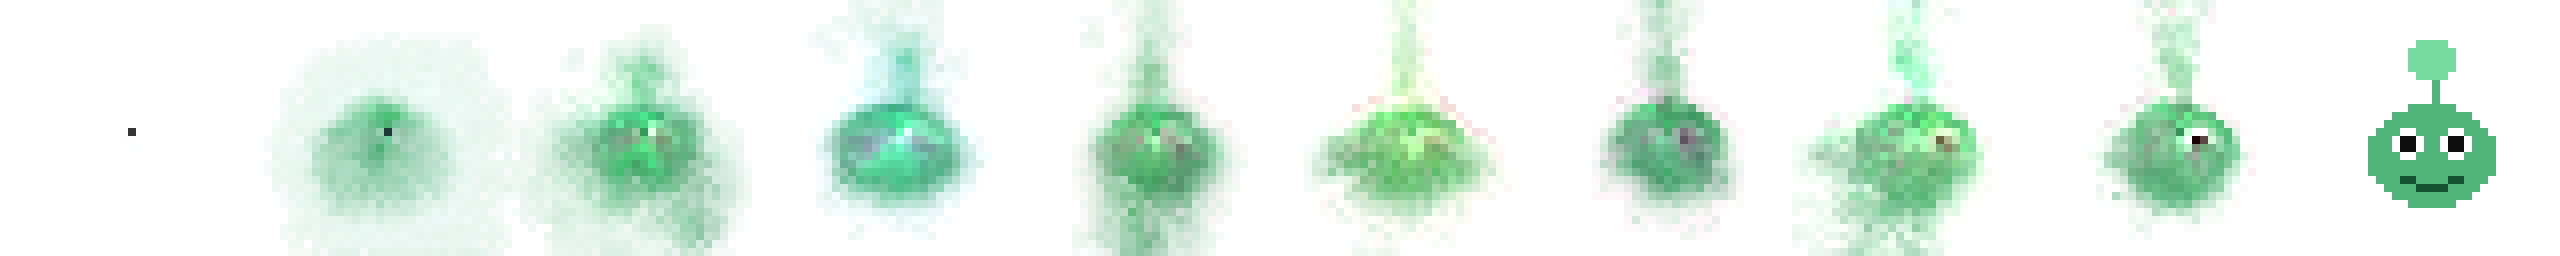

Regeneration pathway (intact → damaged → after 40 more steps), also under-trained
but clearly attempting to heal:

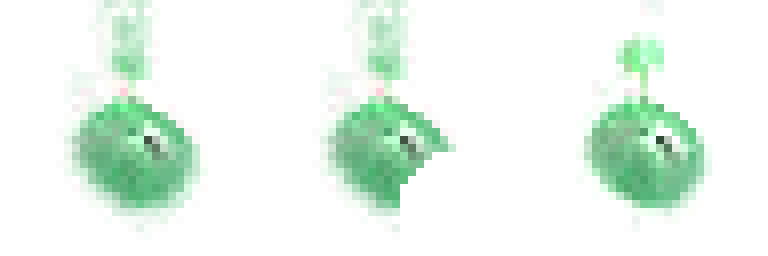

**This notebook scales it up properly on Kaggle's free GPU**: bigger grid, bigger
hidden layer, ~10-20x more training steps. Turn on GPU in Settings → Accelerator
(T4 x2 or P100) before running.

---


In [ ]:
import os, time, copy, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability(0)
    if cap[0] < 7:
        print(f'GPU {torch.cuda.get_device_name(0)} (cap {cap}) is too old for this PyTorch. Falling back to CPU.')
        device = 'cpu'
    else:
        device = 'cuda'
else:
    device = 'cpu'

print("device:", device)
OUT = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
os.makedirs(OUT, exist_ok=True)
torch.manual_seed(0); np.random.seed(0)


In [ ]:
CHANNELS = 16  # 4 visible (RGBA) + 12 hidden

# --- target: procedural shapes for "Open-ended morphogenesis". ---
def make_target(size=40, pad=4, shape="critter"):
    s = size / 40.0
    img = Image.new("RGBA", (size, size), (0, 0, 0, 0))
    d = ImageDraw.Draw(img)
    box = lambda c: [v * s for v in c]
    
    if shape == "critter":
        body, bulb = (80, 180, 120, 255), (120, 220, 160, 255)
        white, dark, line = (255, 255, 255, 255), (15, 15, 15, 255), (20, 80, 50, 255)
        d.ellipse(box([8, 16, 32, 36]), fill=body)
        d.line(box([20, 16, 20, 7]), fill=body, width=max(1, round(2 * s)))
        d.ellipse(box([16, 2, 24, 9]), fill=bulb)
        d.ellipse(box([12, 21, 17, 26]), fill=white)
        d.ellipse(box([23, 21, 28, 26]), fill=white)
        d.ellipse(box([13.5, 22.5, 15.5, 24.5]), fill=dark)
        d.ellipse(box([24.5, 22.5, 26.5, 24.5]), fill=dark)
        d.arc(box([14, 27, 26, 33]), start=20, end=160, fill=line, width=max(1, round(2 * s)))
    elif shape == "square":
        d.rectangle(box([10, 10, 30, 30]), fill=(200, 80, 80, 255))
    elif shape == "circle":
        d.ellipse(box([10, 10, 30, 30]), fill=(80, 80, 200, 255))
    elif shape == "triangle":
        d.polygon(box([20, 10, 10, 30, 30, 30]), fill=(80, 200, 80, 255))

    full = size + 2 * pad
    canvas = Image.new("RGBA", (full, full), (0, 0, 0, 0))
    canvas.paste(img, (pad, pad), img)
    arr = np.array(canvas).astype(np.float32) / 255.0
    arr[..., :3] *= arr[..., 3:4]
    return arr


class Perception(nn.Module):
    def __init__(self, channels=CHANNELS):
        super().__init__()
        ident = torch.tensor([[0., 0, 0], [0, 1, 0], [0, 0, 0]])
        sx = torch.tensor([[-1., 0, 1], [-2, 0, 2], [-1, 0, 1]]) / 8.0
        sy = sx.t()
        kernel = torch.stack([ident, sx, sy]).repeat(channels, 1, 1).unsqueeze(1)
        self.register_buffer("kernel", kernel)
        self.channels = channels

    def forward(self, x):
        return F.conv2d(x, self.kernel, padding=1, groups=self.channels)


class UpdateRule(nn.Module):
    def __init__(self, channels=CHANNELS, hidden=128):
        super().__init__()
        self.channels = channels
        self.perceive = Perception(channels)
        self.fc1 = nn.Conv2d(channels * 3, hidden, 1)
        self.fc2 = nn.Conv2d(hidden, channels, 1)
        nn.init.zeros_(self.fc2.weight); nn.init.zeros_(self.fc2.bias)

    def forward(self, x, update_rate=0.5, noise_std=0.0):
        y = F.relu(self.fc1(self.perceive(x)))
        dx = self.fc2(y)
        if noise_std > 0:
            dx = dx + torch.randn_like(dx) * noise_std
        mask = (torch.rand(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device) <= update_rate).float()
        x = x + dx * mask
        alive = F.max_pool2d(x[:, 3:4], 3, stride=1, padding=1) > 0.1
        return x * alive.float()


def make_seed(size, n=1, channels=CHANNELS, device="cpu", dna=None):
    x = torch.zeros(n, channels, size, size, device=device)
    x[:, 3, size // 2, size // 2] = 1.0
    if dna is not None:
        x[:, 4:4+dna.shape[1], size // 2, size // 2] = dna
    else:
        x[:, 4:, size // 2, size // 2] = 1.0
    return x

def to_rgb(x):
    rgb, a = x[:, :3], torch.clamp(x[:, 3:4], 0, 1)
    return torch.clamp(1.0 - a + rgb, 0, 1)


class SamplePool:
    def __init__(self, seed_func, size=1024):
        self.size = size
        self.seed_func = seed_func
        self.slots = None

    def sample(self, n, device="cpu"):
        if self.slots is None:
            self.slots = self.seed_func(n=self.size).cpu()
        idx = np.random.choice(self.size, n, replace=False)
        return idx, self.slots[idx].clone().to(device)

    def commit(self, idx, batch):
        self.slots[idx] = batch.detach().cpu()


def damage_batch(x, n_damaged=0):
    if n_damaged == 0: return x
    x = x.clone()
    B, C, H, W = x.shape
    yy, xx = torch.meshgrid(torch.arange(H, device=x.device), torch.arange(W, device=x.device), indexing="ij")
    for i in range(n_damaged):
        cy, cx = np.random.randint(0, H), np.random.randint(0, W)
        r = np.random.randint(H // 6, H // 3)
        mask = ((yy - cy) ** 2 + (xx - cx) ** 2) > r * r
        x[-(i + 1)] *= mask.float()
    return x


def train_step(model, opt, pool, target, steps_range=(48, 64), batch_size=8, n_damaged=3, device="cpu", noise_std=0.0):
    idx, x = pool.sample(batch_size, device=device)
    losses_pre = ((x[:, :4] - target) ** 2).mean(dim=[1, 2, 3])
    worst = torch.argmax(losses_pre).item()
    x[worst] = pool.seed_func(n=1).to(device)[0]
    x = damage_batch(x, n_damaged=min(n_damaged, batch_size - 1))

    for _ in range(np.random.randint(*steps_range)):
        x = model(x, noise_std=noise_std)

    loss = ((x[:, :4] - target) ** 2).mean()
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()
    pool.commit(idx, x)
    return loss.item()


In [ ]:
SIZE, PAD = 40, 4
SHAPES = ["critter", "square", "circle", "triangle"]
DNA_DIM = 4
DNA_MAP = {s: torch.eye(DNA_DIM)[i].unsqueeze(0) for i, s in enumerate(SHAPES)}

TARGET_MAP = {}
for s in SHAPES:
    t_np = make_target(size=SIZE, pad=PAD, shape=s)
    TARGET_MAP[s] = torch.tensor(t_np).permute(2, 0, 1).unsqueeze(0).to(device)

H = W = TARGET_MAP["critter"].shape[-1]
model = UpdateRule(channels=CHANNELS, hidden=128).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[3000, 7000], gamma=0.3)

POOLS = {}
for s in SHAPES:
    def get_seed_func(shape_name=s):
        def seed_func(n=1):
            dna = DNA_MAP[shape_name].repeat(n, 1)
            return make_seed(H, n=n, dna=dna, device="cpu")
        return seed_func
    POOLS[s] = SamplePool(get_seed_func(s), size=256)

N_ITERS = 12000
CAPTURE_EVERY = 200
frames = {s: [] for s in SHAPES}
losses = []

t0 = time.time()
for i in range(N_ITERS):
    s = np.random.choice(SHAPES)
    target = TARGET_MAP[s]
    pool = POOLS[s]
    
    noise_std = 0.01 if i > 1000 else 0.0
    loss = train_step(model, opt, pool, target, steps_range=(48, 64),
                       batch_size=8, n_damaged=3, device=device, noise_std=noise_std)
    sched.step()
    losses.append(loss)
    
    if i % CAPTURE_EVERY == 0 or i == N_ITERS - 1:
        with torch.no_grad():
            for s_cap in SHAPES:
                dna = DNA_MAP[s_cap]
                x = make_seed(H, 1, CHANNELS, device, dna=dna)
                for _ in range(64):
                    x = model(x)
                rgb = to_rgb(x)[0].permute(1, 2, 0).clamp(0, 1).cpu().numpy()
                frames[s_cap].append(rgb)
        if i % 500 == 0 or i == N_ITERS - 1:
            print(f"\niter {i:5d}  loss {loss:.5f}  elapsed {time.time()-t0:6.1f}s")

print(f"\ndone: {N_ITERS} iters in {time.time()-t0:.1f}s")
torch.save(model.state_dict(), f"{OUT}/nca_model.pt")


In [ ]:
plt.figure(figsize=(6,3))
plt.plot(losses); plt.yscale("log")
plt.xlabel("iteration"); plt.ylabel("loss (log scale)"); plt.title("training loss")
plt.tight_layout(); plt.savefig(f"{OUT}/loss_curve.png", dpi=120); plt.show()


In [ ]:
scale = 6
for s in SHAPES:
    imgs = [Image.fromarray((f*255).astype(np.uint8)).resize((H*scale, H*scale), Image.NEAREST) for f in frames[s]]
    gif_path = f"{OUT}/growth_{s}.gif"
    imgs[0].save(gif_path, save_all=True, append_images=imgs[1:], duration=100, loop=0)
    print("saved", gif_path)
    display(IPImage(filename=gif_path))


## Regeneration test

Grow it once, then repeatedly punch holes in it and just keep stepping the
*same* rule with no further training. If the pool-based training worked, it
should patch itself back up each time — the rule has no concept of "damage",
it only ever reacts to what it locally sees, so healing is an emergent
property, not a programmed one.

In [ ]:
with torch.no_grad():
    s_test = "critter"
    dna = DNA_MAP[s_test]
    x = make_seed(H, 1, CHANNELS, device, dna=dna)
    for _ in range(64):
        x = model(x)

    regen_frames = [to_rgb(x)[0].permute(1,2,0).clamp(0,1).cpu().numpy()]
    for round_i in range(4):
        x = damage_batch(x, n_damaged=1)
        regen_frames.append(to_rgb(x)[0].permute(1,2,0).clamp(0,1).cpu().numpy())
        for _ in range(50):
            x = model(x, noise_std=0.01)
            regen_frames.append(to_rgb(x)[0].permute(1,2,0).clamp(0,1).cpu().numpy())

imgs = [Image.fromarray((f*255).astype(np.uint8)).resize((H*scale,H*scale), Image.NEAREST) for f in regen_frames[::3]]
gif_path = f"{OUT}/regen.gif"
imgs[0].save(gif_path, save_all=True, append_images=imgs[1:], duration=70, loop=0)
print("saved", gif_path, "-", len(regen_frames), "frames, 4 damage rounds")
display(IPImage(filename=gif_path))


---
## Going further (optional — "we have time")

Three quick extensions on top of the trained rule, no retraining required:
1. **Colony** — scatter several seeds in one big canvas and watch independent
   organisms emerge side by side from the *same* shared rule.
2. **Mutants** — perturb the rule's weights slightly and watch the phenotype
   drift. A crude window into how much slack the learned rule has.
3. **Ideas to actually rerun with**: swap `make_target` for a different
   procedural shape, push `CHANNELS` up/down, train two rules on two
   different targets, then drop both into one canvas and see who wins
   territory.

In [ ]:
# 1. multi-seed colony with different DNAs
canvas = 3 * H
xc = torch.zeros(1, CHANNELS, canvas, canvas, device=device)
n_seeds = 8
rng = np.random.default_rng(1)
for _ in range(n_seeds):
    py, px = rng.integers(10, canvas-10), rng.integers(10, canvas-10)
    s_name = rng.choice(SHAPES)
    dna = DNA_MAP[s_name]
    xc[0, 3, py, px] = 1.0
    xc[0, 4:4+DNA_DIM, py, px] = dna.to(device)

with torch.no_grad():
    for _ in range(150):
        xc = model(xc)
colony_rgb = to_rgb(xc)[0].permute(1,2,0).clamp(0,1).cpu().numpy()
Image.fromarray((colony_rgb*255).astype(np.uint8)).resize((canvas*4, canvas*4), Image.NEAREST)\n    .save(f"{OUT}/colony.png")
plt.figure(figsize=(8,8)); plt.imshow(colony_rgb); plt.axis("off")
plt.title(f"{n_seeds} seeds with mixed DNA, one shared rule"); plt.show()


In [ ]:
# 2. weight-mutation siblings
n_mutants = 6
mutant_imgs = []
for k in range(n_mutants):
    mutant = copy.deepcopy(model)
    noise_scale = 0.02 * (k + 1)
    with torch.no_grad():
        mutant.fc1.weight += torch.randn_like(mutant.fc1.weight) * noise_scale
    xs = make_seed(H, 1, CHANNELS, device)
    with torch.no_grad():
        for _ in range(64):
            xs = mutant(xs)
    mutant_imgs.append(to_rgb(xs)[0].permute(1,2,0).clamp(0,1).cpu().numpy())

fig, axes = plt.subplots(1, n_mutants, figsize=(2.2*n_mutants, 2.4))
for ax, im, k in zip(axes, mutant_imgs, range(n_mutants)):
    ax.imshow(im); ax.axis("off"); ax.set_title(f"noise {0.02*(k+1):.2f}", fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/mutants.png", dpi=120); plt.show()


---
### What you now have in `/kaggle/working/`
`nca_model.pt` (trained weights, ~load with `UpdateRule().load_state_dict(...)`),
`growth.gif`, `regen.gif`, `colony.png`, `mutants.png`, `loss_curve.png`.

The whole rule is one ~128-hidden-unit, 1x1-conv MLP applied identically to
every pixel — on the order of 10-20k parameters. Everything you watched grow,
heal, and mutate came out of that, not out of any explicit shape logic.